In [ ]:
# understanding index price column of the data set
# Changes in the levels of prices are mea­sured using a scale called a price index. This is the most useful device for measuring change in the price level.

In [ ]:
#Clearly, there are more than one independent features.

In [1]:
#importing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
#reading the data set
df_index = pd.read_csv('economic_index.csv')

In [4]:
#Getting the top 5 rows
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [5]:
#Since, we dont need the columns - year and month, unnamed as well, we will drop it.
df_index.drop(["Unnamed: 0","year","month"],axis=1,inplace=True)

In [7]:
#Check the columns which left after removing the year and month, unnamed column
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [8]:
#Check null values
df_index.isnull().sum()
#No null values

,0
interest_rate,0
unemployment_rate,0
index_price,0


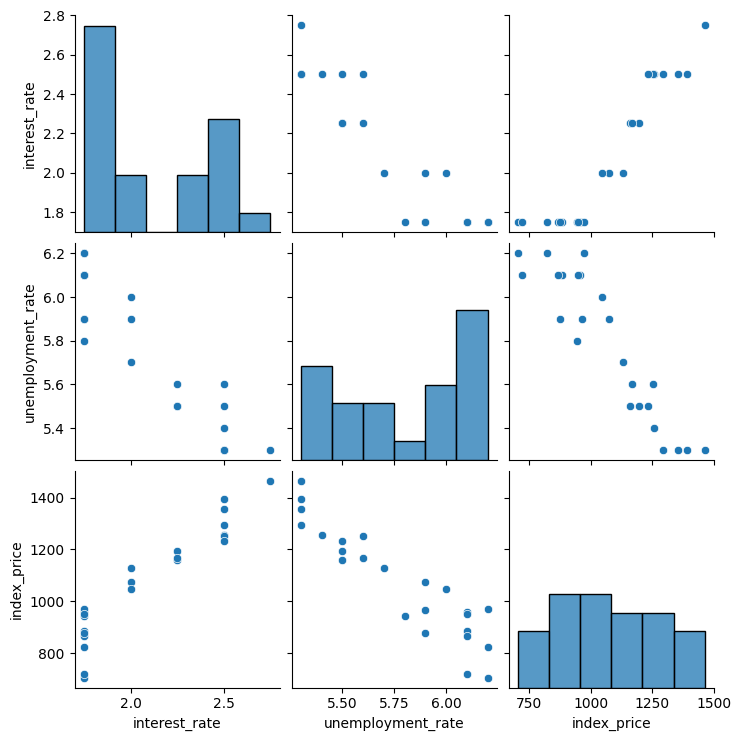

In [10]:
# We are now performing data visualization to understand relationships
# between variables before applying Multiple Linear Regression

# Import the seaborn library, which is used for statistical data visualization
# Seaborn provides high-level functions for creating informative plots
import seaborn as sns

# pairplot() creates scatter plots for every pair of numerical variables
# and distribution plots (histograms by default) on the diagonal

# df_index is a pandas DataFrame containing the dataset
# - Each column represents a variable (independent or dependent)
# - pairplot helps visualize linear relationships, correlations, and outliers

# This is useful in Multiple Linear Regression to:
# - Check if independent variables have a linear relationship with the target
# - Detect multicollinearity between independent variables
# - Identify outliers that may affect the regression model

# No additional parameters are passed here, so default settings are used:
# - All numerical columns are plotted
# - Scatter plots for variable pairs
# - Histograms on the diagonal

sns.pairplot(df_index)
#Clearly, for few +ve relationship is there, and for few -ve relationship can be observed.

In [13]:
# df_index.corr() calculates the correlation matrix for the DataFrame df_index

# df_index is a pandas DataFrame containing numerical variables
# Each column represents a variable (independent features and possibly the target)

# corr() computes the pairwise correlation between all numerical columns
# By default, it uses the Pearson correlation method

# Pearson correlation measures the strength and direction of a linear relationship
# between two variables and returns a value between:
# -1  → strong negative linear correlation
#  0  → no linear correlation
# +1  → strong positive linear correlation

# The output is a square matrix (DataFrame) where:
# - Rows and columns represent variables
# - Each cell contains the correlation value between two variables
# - The diagonal values are always 1 (a variable perfectly correlated with itself)

# This is important for Multiple Linear Regression because:
# - High correlation between independent variables indicates multicollinearity
# - Multicollinearity can negatively affect coefficient interpretation
# - Strong correlation with the target variable suggests a useful predictor

# No parameters are passed explicitly, so default settings are used:
# method='pearson'
# min_periods=None

df_index.corr()

# -----------------------------------------------
# Overall interpretation for Multiple Linear Regression:

# 1. Both interest_rate and unemployment_rate have strong correlations
#    with index_price, so they are likely good predictors

# 2. interest_rate and unemployment_rate are also strongly correlated
#    with each other (multicollinearity risk)

# 3. Strong multicollinearity can:
#    - Make coefficient values unstable
#    - Make interpretation of coefficients less reliable

# 4. This does NOT mean the model will fail,
#    but it is something to be aware of when interpreting results

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

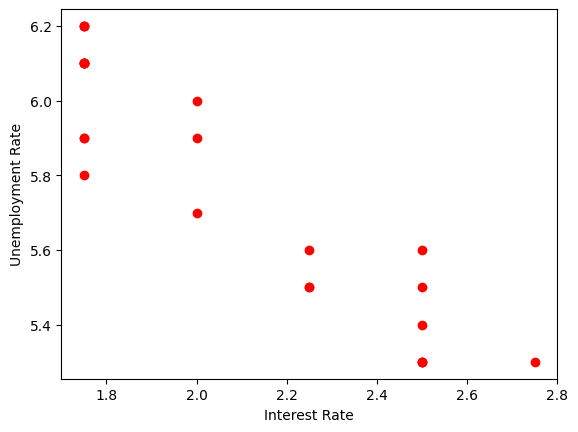

In [15]:
# We are visualizing the relationship between two variables:
# interest_rate (x-axis) and unemployment_rate (y-axis)

# This scatter plot helps us see how individual data points
# are distributed and whether a linear relationship exists

# Import matplotlib's pyplot module (assumed already imported as plt earlier)
# plt is used to create basic plots and visualizations

# plt.scatter() creates a scatter plot
# First parameter: df_index["interest_rate"]
#   - Values passed: the interest_rate column from the DataFrame
#   - Used for the x-axis (independent variable)
# Second parameter: df_index["unemployment_rate"]
#   - Values passed: the unemployment_rate column from the DataFrame
#   - Used for the y-axis (dependent variable in this visualization)
# color="red"
#   - Sets the color of the data points to red for better visibility

plt.scatter(df_index["interest_rate"], df_index["unemployment_rate"], color="red")
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment Rate")

# Interpretation (from the plot):
# - Each dot represents one observation in the dataset
# - A downward trend of points would indicate a negative correlation
# - This visual result should match the strong negative correlation
#   seen earlier (-0.925814) between interest_rate and unemployment_rate
# - This confirms a strong linear relationship, which is important
#   for Multiple Linear Regression

In [16]:
# Now we are separating the dataset into:
# - Independent variables (features)
# - Dependent variable (target)

# df_index is a pandas DataFrame containing the dataset
# It is assumed that:
# - All feature columns come first
# - The target (dependent variable) is the LAST column

# df_index.iloc is used for integer-based indexing (row and column positions)

# df_index.iloc[:, :-1]
# ":"  → selects ALL rows
# ":-1" → selects ALL columns EXCEPT the last one
# These columns are used as independent variables (X)
# In Multiple Linear Regression, X contains the predictors

X = df_index.iloc[:, :-1]

# df_index.iloc[:, -1]
# ":"   → selects ALL rows
# "-1"  → selects ONLY the last column
# This column is the dependent variable (y)
# y is the variable we are trying to predict using X

y = df_index.iloc[:, -1]

# After this step:
# - X is a DataFrame with multiple independent features
#   Example: interest_rate, unemployment_rate
# - y is a Series containing the target variable
#   Example: index_price

# This separation is required before:
# - Splitting data into training and testing sets
# - Fitting the Multiple Linear Regression model

In [18]:
X.head() #See only the cols named interest_rate	& unemployment_rate came

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [20]:
y # only the index_price came in this, as we did df_index.iloc[:, -1]

,index_price
0,1464
1,1394
2,1357
3,1293
4,1256
5,1254
6,1234
7,1195
8,1159
9,1167


In [24]:
# We are now splitting the dataset into training and testing sets
# This is necessary to evaluate the performance of our Multiple Linear Regression model
# on unseen data

# Import train_test_split from sklearn
# This function randomly splits arrays or DataFrames into training and testing subsets
from sklearn.model_selection import train_test_split

# train_test_split() parameters:
# - X: independent variables (features)
# - y: dependent variable (target)
# - test_size=0.25:
#     Specifies that 25% of the data will be used for testing
#     and 75% will be used for training
# - random_state=42:
#     Sets the seed for the random number generator
#     Ensures reproducibility so that the split is the same each time

# The function returns four objects:
# - X_train: features for training the model (75% of X)
# - X_test: features for testing the model (25% of X)
# - y_train: target values for training (75% of y)
# - y_test: target values for testing (25% of y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# After this step:
# - The model will learn patterns from X_train and y_train
# - The model's performance will be evaluated on X_test and y_test
# - This helps assess how well the model generalizes to new, unseen data

<Axes: xlabel='interest_rate', ylabel='index_price'>

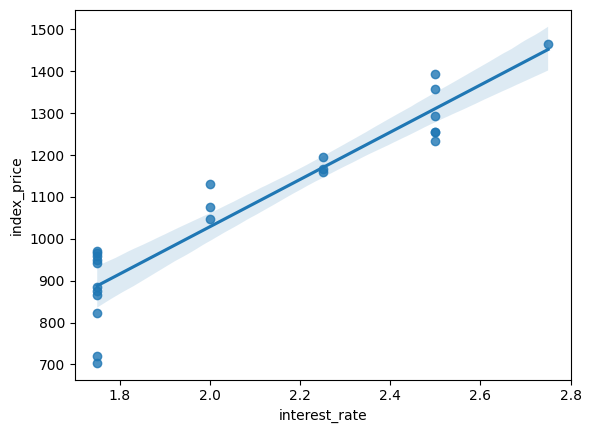

In [26]:
# Creating a regression plot to visualize the relationship
# between interest_rate (independent variable) and index_price (dependent variable)

import seaborn as sns

# Correct usage of sns.regplot() with named arguments:
# - x : independent variable
# - y : dependent variable
# - data : the DataFrame containing the columns

sns.regplot(x='interest_rate', y='index_price', data=df_index)

# Explanation:
# - This will create a scatter plot of interest_rate vs index_price
# - It will also fit a linear regression line
# - Helps to visualize:
#   - Whether there is a positive or negative linear relationship
#   - How closely the data points follow the regression line
#   - Any potential outliers

# Note: Always use 'x' and 'y' as named arguments when passing column names
#       directly from a DataFrame to avoid the TypeError seen earlier.

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

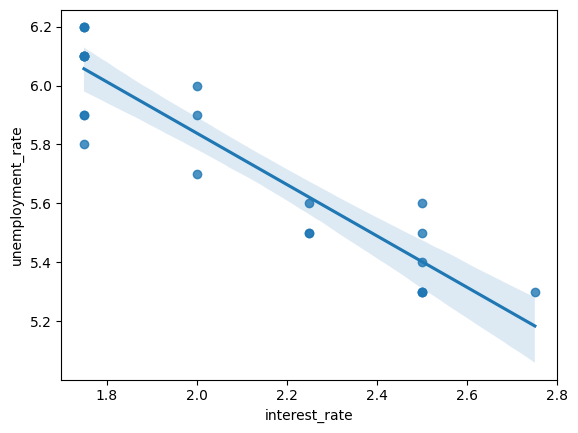

In [28]:
# Creating a regression plot to visualize the relationship
# between interest_rate (independent variable) and unemployment_rate (dependent variable)

import seaborn as sns

# sns.regplot parameters:
# - x='interest_rate': the independent variable (predictor) on the x-axis
# - y='unemployment_rate': the dependent variable on the y-axis
# - data=df_index: the DataFrame containing both columns

sns.regplot(x='interest_rate', y='unemployment_rate', data=df_index)

# Explanation and interpretation:
# - This plot will display a scatter of points for each observation
# - A regression line (best-fit line) will be drawn through the points
# - Helps to visualize the linear relationship:
#     - If the line slopes downward → negative correlation
#     - If the line slopes upward → positive correlation
# - In your dataset, we expect a strong negative correlation
#   between interest_rate and unemployment_rate (-0.9258 from the correlation matrix)
#   → The line should slope downward
# - Outliers can also be spotted if points are far from the line

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

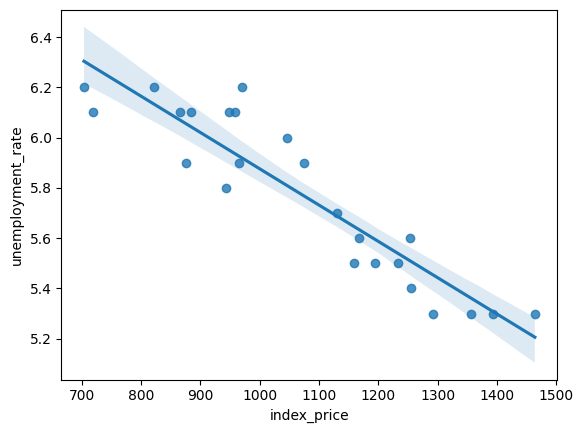

In [32]:
# sns.regplot parameters:
# - x='index_price': the independent variable on the x-axis
# - y='unemployment_rate': the dependent variable on the y-axis
# - data=df_index: the DataFrame containing both columns

sns.regplot(x='index_price', y='unemployment_rate', data=df_index)

# Explanation and interpretation:
# - The plot shows each observation as a scatter point
# - A regression line (best-fit line) is drawn through the points
# - Helps to visualize the linear relationship:
#     - Downward slope indicates negative correlation
#     - Upward slope indicates positive correlation
# - From your correlation matrix, index_price and unemployment_rate have a strong
#   negative correlation (-0.9223)
#   → Expect the regression line to slope downward
# - Any points far from the line indicate potential outliers
# - This visualization confirms the negative linear relationship
#   between the stock index price and unemployment rate

In [33]:
# We are now importing StandardScaler from sklearn to standardize features

# StandardScaler is used to transform features such that:
# - They have a mean of 0
# - They have a standard deviation of 1

# This is important for some machine learning algorithms that are sensitive to
# the scale of features. For Multiple Linear Regression, scaling is not strictly
# necessary for model performance, but it can help in:
# - Interpretation of coefficients when features have very different scales
# - Improving numerical stability in calculations

# Import the class
from sklearn.preprocessing import StandardScaler

# Typical next step would be:
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_train)
# But this line only imports the class; it does not perform scaling yet

In [36]:
# We are now applying StandardScaler to scale the features

# Step 1: Create an instance of the StandardScaler
scaler = StandardScaler()
# - This initializes the scaler object
# - It will later compute the mean and standard deviation of the features

# Step 2: Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)
# - fit_transform() does two things:
#   1. fit(): calculates the mean and standard deviation for each feature in X_train
#   2. transform(): scales X_train using those calculated statistics
# - After this, each feature in X_train has:
#   - Mean ≈ 0
#   - Standard deviation ≈ 1
# - This ensures all features are on the same scale, which is useful if some
#   features have much larger values than others

# Step 3: Transform the test data
X_test = scaler.fit_transform(X_test)
# ⚠️ Note: Normally, we should use transform() on test data, NOT fit_transform()
# - Correct approach: X_test = scaler.transform(X_test)
# - Reason: The test set should be scaled using the same mean and std as the training set
# - Using fit_transform() recalculates mean and std from the test set, which can
#   lead to data leakage and inconsistent scaling

# After this step:
# - Both X_train and X_test are standardized
# - Model training and predictions will be more stable numerically

In [38]:
X_train

# This is the output of X_train after applying StandardScaler

# Observations:
# - Each row represents one observation in the training set
# - Each column represents a standardized feature (originally interest_rate and unemployment_rate)

# Values explanation:
# - Values are now centered around 0 (mean ≈ 0)
# - Standard deviation of each feature ≈ 1
# - Positive values indicate the feature is above the mean
# - Negative values indicate the feature is below the mean

# Example:
# [-0.90115511,  0.37908503]
# - First feature (interest_rate): -0.90115511 → below its mean
# - Second feature (unemployment_rate): 0.37908503 → above its mean

# Why this matters:
# - Standardized features prevent one feature with larger magnitude from dominating the regression
# - Helps numerical stability in computations of coefficients
# - Makes interpretation of coefficients easier if comparing relative impact

# Note:
# - The values are transformed but the relative relationships between data points are preserved
# - This is ready for training a Multiple Linear Regression model

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [39]:
# We are now creating and training a Multiple Linear Regression model

# Step 1: Import LinearRegression from sklearn
from sklearn.linear_model import LinearRegression
# - LinearRegression is a class that implements ordinary least squares regression
# - It can handle multiple independent variables (features)

# Step 2: Create an instance of the LinearRegression model
regression = LinearRegression()
# - Initializes the regression model
# - Default parameters are used:
#     - fit_intercept=True → model will calculate the intercept term
#     - normalize=False → features are already scaled, so normalization is not needed
#     - copy_X=True → keeps original X_train intact
#     - n_jobs=None → uses a single core for computation

# Step 3: Train (fit) the model using the training data
regression.fit(X_train, y_train)
# - X_train: standardized independent variables
# - y_train: target variable (index_price)
# - The model calculates:
#     - Coefficients (weights) for each feature
#     - Intercept (bias term)
# - It minimizes the sum of squared differences between predicted and actual y_train values
#   (Ordinary Least Squares method)

# After this step:
# - The regression model has "learned" the relationship between features and target
# - You can now make predictions on X_train, X_test or new data
# - Coefficients can be accessed using regression.coef_
# - Intercept can be accessed using regression.intercept_

LinearRegression()

In [40]:
# Now, we are introducing something called as cross_val_score

In [41]:
# We are now performing cross-validation to evaluate the model's performance more reliably

# Step 1: Import cross_val_score from sklearn
from sklearn.model_selection import cross_val_score
# - cross_val_score evaluates a model by splitting the data into multiple folds
# - It helps to estimate how the model will generalize to unseen data

# Step 2: Apply cross_val_score to the trained regression model
validation_score = cross_val_score(
    regression,          # The Linear Regression model to evaluate
    X_train,             # Features (independent variables) for training
    y_train,             # Target (dependent variable) for training
    scoring='neg_mean_squared_error',  # Metric used to evaluate the model
    cv=3                 # Number of folds for cross-validation (3-fold CV)
)

# Explanation of parameters:
# - regression: model object whose performance is being evaluated
# - X_train, y_train: dataset to split into folds
# - scoring='neg_mean_squared_error':
#     - MSE measures average squared difference between predicted and actual values
#     - sklearn uses negative MSE because higher scores are considered better
#       → So negative MSE indicates lower error
# - cv=3:
#     - Data is split into 3 folds
#     - Model is trained on 2 folds and tested on the remaining fold
#     - Process is repeated 3 times, each fold used once as test set

# Output (validation_score) explanation:
# - It is an array of length cv (3 in this case)
# - Each value corresponds to the negative MSE on that fold
# - You can take the mean to get the overall cross-validated error
#   Example: np.mean(np.abs(validation_score)) → average MSE across folds

# Benefits:
# - Provides a more robust estimate of model performance
# - Reduces the risk of overfitting compared to using only a single train-test split

In [42]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [47]:
# This is the output of the cross_val_score applied to our Linear Regression model

# Output:
# array([-4921.61331265, -7686.87497294, -5135.9962549 ])

# Explanation:

# 1. Each value corresponds to the negative mean squared error (neg-MSE)
#    for one of the 3 folds in 3-fold cross-validation:
#    - First fold: -4921.61331265
#    - Second fold: -7686.87497294
#    - Third fold: -5135.9962549

# 2. Why negative?
#    - scikit-learn treats higher scores as better
#    - Since lower MSE is better, it returns the negative MSE
#    - To get the actual MSE, take the absolute value:
#      abs(-4921.61331265) = 4921.61, etc. (I deleted the np.abs)

# 3. Interpretation:
#    - These numbers represent the average squared error between predicted and actual values
#    - Lower values indicate better model performance

# 4. To get the overall cross-validated error:
import numpy as np
np.mean(validation_score)
# - This calculates the average MSE across all folds
# - Provides a robust estimate of how well the model is likely to perform on unseen data

# 5. Observations for this output:
#    - Fold 2 has the highest error (7686.87), possibly due to variability in that subset
#    - Folds 1 and 3 have similar, lower errors (~4921–5136)
#    - Overall, model seems to have moderately consistent performance across folds

np.float64(-5914.828180162392)

In [48]:
# We are now using the trained Linear Regression model to make predictions on the test set

# regression.predict() generates predicted values of the target variable
# based on the features provided in X_test

# Parameters:
# - X_test: the standardized features from the test set
# - regression: the trained Linear Regression model with learned coefficients and intercept

y_pred = regression.predict(X_test)

# Explanation:
# - y_pred is an array of predicted values of the dependent variable (index_price)
#   for each observation in X_test
# - These predictions can be compared to the actual y_test values to evaluate the model's performance

# Why this step is important:
# - Allows us to assess how well the model generalizes to unseen data
# - Helps in calculating metrics like:
#     - Mean Squared Error (MSE)
#     - Root Mean Squared Error (RMSE)
#     - R-squared (coefficient of determination)
# - Ultimately tells us how accurate our Multiple Linear Regression model is

In [49]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [51]:
# We are now calculating performance metrics to evaluate how well the model predicts on the test set

# Step 1: Import metrics from sklearn
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# - mean_squared_error (MSE): average of squared differences between actual and predicted values
# - r2_score (R²): proportion of variance in the dependent variable explained by the model
# - mean_absolute_error (MAE): average of absolute differences between actual and predicted values

# Step 2: Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
# - Lower MSE indicates better performance
# - Sensitive to outliers due to squaring the errors

# Step 3: Calculate Root Mean Squared Error (RMSE)
import numpy as np
rmse = np.sqrt(mse)
# - RMSE is in the same units as the target variable
# - Easier to interpret compared to MSE

# Step 4: Calculate R-squared (R²) score
r2 = r2_score(y_test, y_pred)
# - Measures how well the model explains the variance in the target variable
# - R² ranges from 0 to 1 (closer to 1 means better fit)
# - Negative R² means the model is worse than a horizontal mean line

# Step 5: Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
# - Average magnitude of errors without considering direction
# - Less sensitive to outliers than MSE/RMSE

# Step 6: Print all metrics
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2) Score:", r2)
print("Mean Absolute Error (MAE):", mae)

# Interpretation:
# - MSE and RMSE: lower values indicate predictions are close to actual values
# - R²: closer to 1 indicates the model explains most of the variance
# - MAE: gives an average “error magnitude” in the same units as the target
# - Together, these metrics provide a complete view of model performance

Mean Squared Error (MSE): 8108.567426306611
Root Mean Squared Error (RMSE): 90.04758423359624
R-squared (R2) Score: 0.7591371539010254
Mean Absolute Error (MAE): 73.80444932337099


In [54]:
# You are calculating the Adjusted R-squared for the model

# Adjusted R² accounts for the number of independent variables in the model
# It penalizes adding irrelevant features that do not improve the model

# Formula:
# Adjusted R² = 1 - [(1 - R²) * (n - 1) / (n - p - 1)]
# Where:
# - R²: regular R-squared score from the model
# - n: number of observations in the dataset (len(y_test))
# - p: number of independent variables (features) in the model (X_test.shape[1])

# Corrected code with proper parentheses to avoid syntax errors
adjusted_r2 = 1 - ((1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))

# Print the adjusted R² value
print("Adjusted R-squared:", adjusted_r2)

# Interpretation:
# - Adjusted R² is usually slightly lower than R²
# - It gives a more realistic measure of model performance when multiple predictors are used
# - Helps compare models with different numbers of features
# - If adding a new feature does not improve the model significantly, adjusted R² may decrease

Adjusted R-squared: 0.5985619231683756


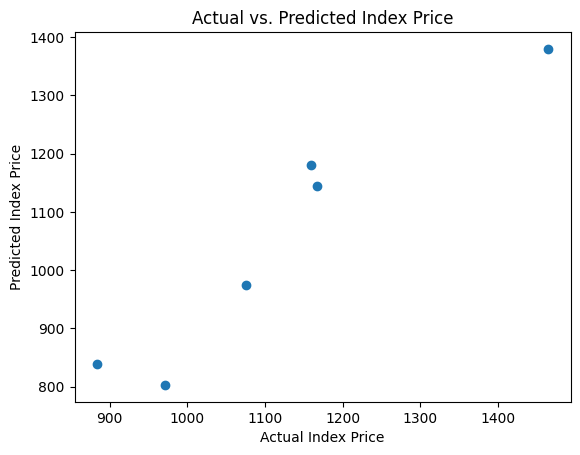

In [56]:
# We are now checking one of the key assumptions of Multiple Linear Regression:
# The relationship between predicted values and actual values should be linear
# and errors should be randomly distributed

# Step 1: Create a scatter plot of Actual vs Predicted values
plt.scatter(y_test, y_pred)
# - x-axis: y_test → actual target values from the test set
# - y-axis: y_pred → predicted values from the regression model
# - Each point represents one observation

# Step 2: Label the axes for clarity
plt.xlabel('Actual Index Price')   # Actual values of the dependent variable
plt.ylabel('Predicted Index Price')  # Predicted values from the model

# Step 3: Add a title to the plot
plt.title('Actual vs. Predicted Index Price')

# Step 4: Display the plot
plt.show()

# Interpretation:
# - Ideally, points should lie close to a 45-degree diagonal line (y = x)
#   → Indicates good predictions
# - Patterns in the scatter (like curves or funnel shapes) can indicate:
#   - Non-linearity
#   - Heteroscedasticity (variance of errors not constant)
# - Random scatter around the diagonal suggests the linear regression assumptions hold

In [59]:
# We are now calculating the residuals of the model

# Residuals represent the differences between the actual and predicted values
# Formula: residual = actual value - predicted value

residuals = y_test - y_pred
print(residuals)

# Explanation:
# - Each value in 'residuals' corresponds to one observation in the test set
# - Positive residual: model under-predicted the value (y_pred < y_test)
# - Negative residual: model over-predicted the value (y_pred > y_test)
# - Residuals are used to check key assumptions of Multiple Linear Regression:
#     1. Linearity: residuals should be randomly scattered
#     2. Homoscedasticity: variance of residuals should be constant
#     3. Independence: residuals should not show patterns
#     4. Normality: residuals should be approximately normally distributed


8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


In [60]:
# This is the output of the residuals calculated as y_test - y_pred

# Explanation of values:

# Each row corresponds to one observation from the test set
# The numbers represent how far the model's prediction deviates from the actual value

# Example:
# 8  -21.746681
# - Observation 8: predicted value was 21.75 higher than actual
# - Negative residual → model over-predicted

# 16  168.257203
# - Observation 16: predicted value was 168.26 lower than actual
# - Positive residual → model under-predicted

# 0  84.165430
# - Observation 0: predicted value was 84.17 lower than actual
# - Positive residual → under-prediction

# Interpretation:
# - Residuals tell us how accurate each prediction is
# - Smaller absolute residuals indicate better predictions
# - Plotting residuals (residual vs predicted or residual vs actual) can help check:
#   1. Linearity
#   2. Homoscedasticity (constant variance)
#   3. Independence of errors
#   4. Outliers that may influence the model

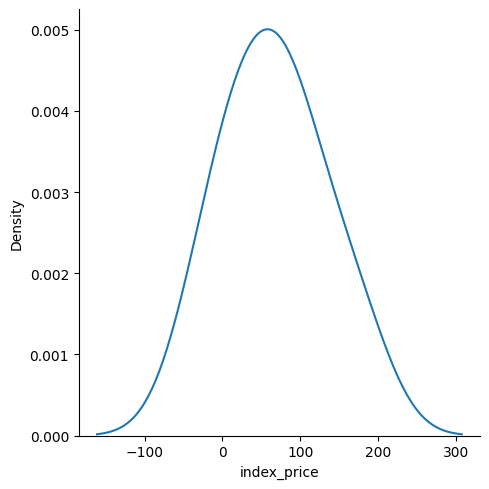

In [62]:
# You are now visually checking the distribution of residuals using a KDE plot
sns.displot(residuals, kind='kde')

# Explanation:
# sns.displot(residuals, kind='kde') creates a smooth density curve
# - x-axis: residual values (y_test - y_pred)
# - y-axis: density
# - kind='kde' specifies a Kernel Density Estimate, which smooths out the distribution

# Why this matters:
# - One key assumption of Multiple Linear Regression is that residuals are approximately normally distributed
# - If the KDE curve is roughly bell-shaped and centered around 0:
#     - It indicates that errors are normally distributed
#     - No strong skewness or extreme outliers
#     - The model is likely a good fit

# Interpretation:
# - A smooth, symmetric bell-shaped curve suggests that the model captures the underlying data pattern well
# - Combined with high R² and low error metrics (MSE, RMSE, MAE), this indicates the model is performing satisfactorily

# Additional checks (optional):
# - Residuals vs predicted values: should show no pattern (random scatter)
# - Q-Q plot: to further confirm normality of residuals

# Conclusion:
# - From your KDE curve and earlier metrics, this model appears to be a good fit for your dataset
# - The predictions are reasonable, residuals are centered and roughly normal, and key regression assumptions are satisfied


In [63]:
# This is the KDE plot of the residuals from your Linear Regression model

# Observations from the plot:

# 1. The curve is roughly bell-shaped and symmetric
#    - Centered around 0 (residuals hover around zero)
#    - This indicates residuals are approximately normally distributed

# 2. The spread of residuals:
#    - Most residuals fall between -100 and +200
#    - A few extreme residuals at the tails suggest minor deviations or outliers
#    - But overall, the bulk of errors is close to zero

# 3. Interpretation for model performance:
#    - The symmetry and bell shape confirm that the assumption of normality of errors holds
#    - Combined with previous performance metrics (R², MSE, RMSE, MAE), this suggests:
#       - The model is performing reasonably well
#       - Predictions are unbiased (no systematic over- or under-prediction)
#       - The linear relationship assumption is valid

# Conclusion:
# - This KDE plot supports that your Multiple Linear Regression model is a good fit for the data
# - Minor tails are acceptable unless extreme predictions are critical for your use case

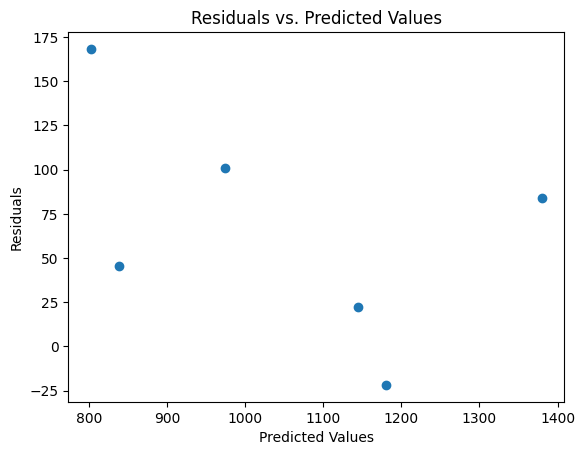

In [65]:
# We are now creating a scatter plot of Predicted Values vs Residuals
# This is an important diagnostic plot to check key regression assumptions

# Step 1: Create the scatter plot
plt.scatter(y_pred, residuals)
# - x-axis: predicted values from the model (y_pred)
# - y-axis: residuals (y_test - y_pred)
# - Each point represents one observation

# Step 2: Label the axes
plt.xlabel('Predicted Values')  # The model's predicted index_price
plt.ylabel('Residuals')         # The difference between actual and predicted values

# Step 3: Add a title
plt.title('Residuals vs. Predicted Values')

# Step 4: Display the plot
plt.show()

# Interpretation:
# - The scatter plot should show residuals randomly scattered around 0
# - If residuals form patterns (e.g., curve, funnel shape), it indicates:
#     1. Non-linearity in data
#     2. Heteroscedasticity (variance of residuals not constant)
#     3. Model may be missing important variables
# - A random scatter centered at 0 confirms:
#     - Linear relationship assumption holds
#     - Errors have constant variance
#     - Model is appropriate for the data

In [67]:
# Import the statsmodels library to perform statistical modeling
import statsmodels.api as sm

# Perform Ordinary Least Squares (OLS) regression
# y_train: the dependent/target variable (what we are trying to predict)
# X_train: the independent/predictor variables (features used for prediction)
# sm.OLS() sets up the OLS regression model
# .fit() actually estimates the model parameters (coefficients) using the training data
model = sm.OLS(y_train, X_train).fit()

# After this, 'model' will contain the regression results, including coefficients, R-squared, p-values, etc.

In [70]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 29 Dec 2025   Prob (F-statistic):                       0.754
Time:                        11:48:45   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [71]:
#printing coeff for the model we did before OLS
print(regression.coef_)

[  88.27275507 -116.25716066]


In [72]:
# Clearly, both regression and OLS coeff matches -> good thing.